<a href="https://colab.research.google.com/github/Aleeza-GH/ML-learning-journey/blob/main/Linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/house_price.csv')

df.sample(5)

,size_sqft,bedrooms,age_years,price
3,1500,4,5,8500000
26,700,2,27,3200000
2,950,2,20,4000000
23,1600,3,5,8200000
15,850,2,16,4400000


In [3]:
df.shape

df.info()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   size_sqft  30 non-null     int64
 1   bedrooms   30 non-null     int64
 2   age_years  30 non-null     int64
 3   price      30 non-null     int64
dtypes: int64(4)
memory usage: 1.1 KB


,0
size_sqft,0
bedrooms,0
age_years,0
price,0


In [4]:
from sklearn.model_selection import train_test_split

X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape

((24, 3), (6, 3))

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

scaler.mean_

array([1162.5       ,    2.79166667,   14.16666667])

In [6]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

lr.coef_

lr.intercept_

np.float64(5987500.0)

In [7]:
y_pred = lr.predict(X_test_scaled)

y_pred

array([7685052.166457  , 4239999.06119154, 8125045.53221052,
       6573908.19704964, 6805065.43494996, 8587375.6548189 ])

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 163925.65888707494
MSE: 29792929545.618053
R2 Score: 0.9850453783652782


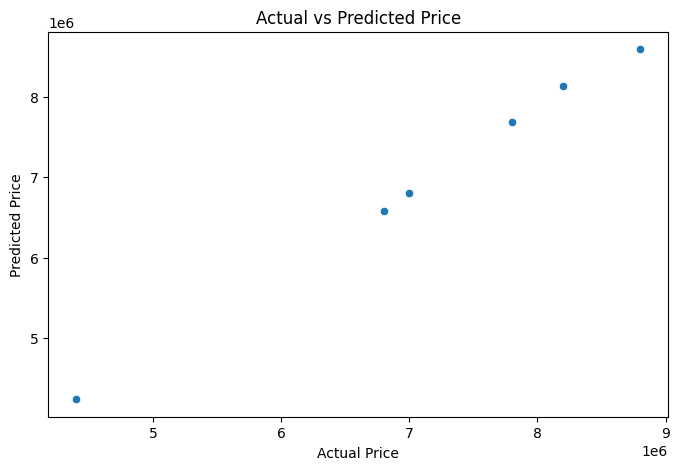

In [9]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price')
plt.show()